In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/breast-cancer.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

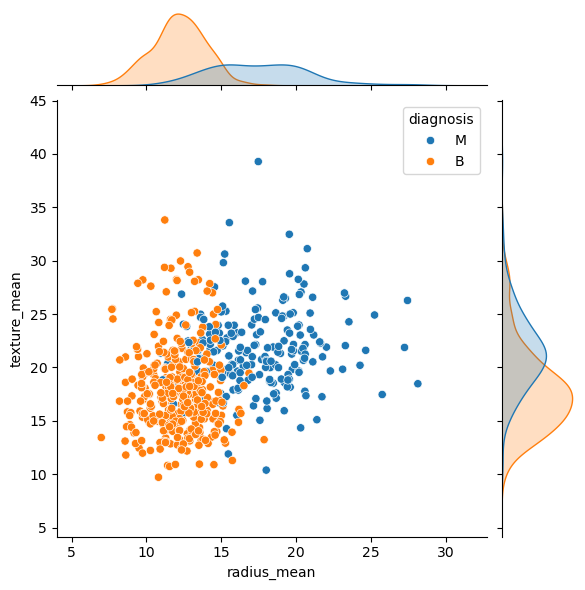

In [5]:
sns.jointplot(data=df, x="radius_mean", y="texture_mean", hue="diagnosis")

## Problema de classificação binária ##

- Classificação **binária**: duas classses (0 e 1);
- Classificação **multiclasse**: n classes (0, 1, ..., n-1), com n > 2

In [6]:
df["diagnosis"].nunique()

2

In [7]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [8]:
df["diagnosis"].value_counts(normalize=True) #Porcentagem

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

## Regressão Logística ##
Modelar a probabilidade de dada observação pertencer a uma das classes.

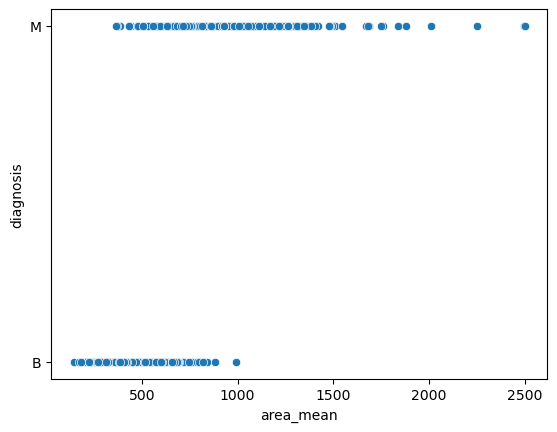

In [9]:
sns.scatterplot(data=df, x="area_mean",y="diagnosis");

In [10]:
df["area_mean"].describe()

count     569.000000
mean      654.889104
std       351.914129
min       143.500000
25%       420.300000
50%       551.100000
75%       782.700000
max      2501.000000
Name: area_mean, dtype: float64

In [11]:
# Transformando em número
# B=0 e M=1
df["diagnosis"].map({"B":0, "M":1})

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

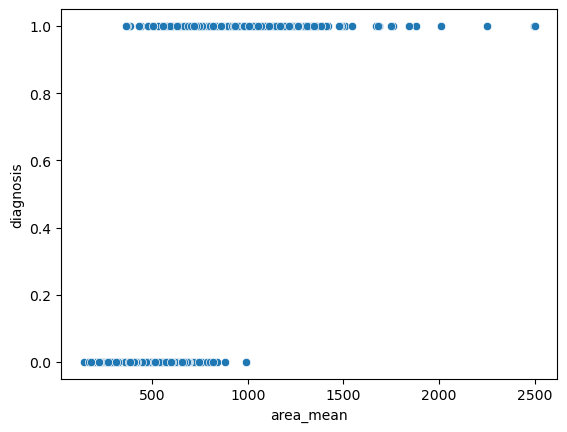

In [12]:
diagnosis_num = df["diagnosis"].map({"B":0, "M":1})
sns.scatterplot(data=df, x="area_mean",y=diagnosis_num);

**Pergunta:** Qual é a probabilidade do tumor ser maligno?

Com o target númerico, é possível atribuir um percentual para um corte (classificação).
- P(x) >= 0.5 => pertence a classe 1
- P(x) < 0.5 => pertence a classe 0

In [13]:
# Separando os dados
X = df.drop(columns=["diagnosis", "id"])
y = df["diagnosis"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [15]:
y.value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [16]:
y_train.value_counts(normalize=True)

diagnosis
B    0.628141
M    0.371859
Name: proportion, dtype: float64

### 1. Construção do Modelo

In [17]:
from sklearn.linear_model import LogisticRegression

# usando o max_iter para caso de estudo apenas
modelo = LogisticRegression(max_iter=3000).fit(X_train, y_train)

### Regressão Logística

A probabilidade é dada por:

$$
P(y=1) = \frac{1}{1 + e^{-(b + w_1 x_1 + w_2 x_2 + \dots + w_n x_n)}}
$$

Onde:

* $b$ é o intercepto. O termo independente, representa o valor inicial da decisão quando todas as variáveis são zero.
* $w_i$ são os coeficientes, os pesos de cada variável.
* $x_i$ são as variáveis (features)


In [18]:
# Intercepto
#Se for positivo → tendência para classe 1
#Se for negativo → tendência para classe 0
modelo.intercept_

array([-27.15592026])

In [19]:
# Problema binário → apenas 1 conjunto de coeficientes
#positivo (+) → aumenta a chance da classe 1
#negativo (-) → diminui a chance da classe 1
modelo.coef_

array([[-0.98444765, -0.277807  ,  0.23375746, -0.02267804,  0.1515268 ,
         0.21510622,  0.41593596,  0.22449603,  0.19728439,  0.03200654,
         0.08943414, -1.24968261,  0.23618402,  0.10406972,  0.0182359 ,
        -0.03975486,  0.03371422,  0.02805968,  0.03793048, -0.00790987,
        -0.15640064,  0.56741511,  0.0926488 ,  0.01593489,  0.24572027,
         0.54857242,  0.9755713 ,  0.39395226,  0.67230604,  0.07702058]])

In [20]:
# 30 features
modelo.coef_.shape

(1, 30)

In [21]:
modelo.feature_names_in_

array(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se',
       'smoothness_se', 'compactness_se', 'concavity_se',
       'concave points_se', 'symmetry_se', 'fractal_dimension_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst',
       'fractal_dimension_worst'], dtype=object)

In [22]:
pd.DataFrame(modelo.coef_[0], index=modelo.feature_names_in_, columns=["parâmetros"])

,parâmetros
radius_mean,-0.984448
texture_mean,-0.277807
perimeter_mean,0.233757
area_mean,-0.022678
smoothness_mean,0.151527
compactness_mean,0.215106
concavity_mean,0.415936
concave points_mean,0.224496
symmetry_mean,0.197284
fractal_dimension_mean,0.032007


In [23]:
y_pred = modelo.predict(X_test)
y_pred

array(['B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'M',
       'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'M', 'B',
       'M', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M',
       'M', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M',
       'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'M',
       'M', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M',
       'B', 'M'], dtype=object)

In [24]:
# probabilidades preditas
y_proba_pred = modelo.predict_proba(X_test)
y_proba_pred

array([[7.10626602e-01, 2.89373398e-01],
       [9.93273184e-01, 6.72681649e-03],
       [9.99609985e-01, 3.90015463e-04],
       [9.97652475e-01, 2.34752538e-03],
       [9.89817374e-01, 1.01826258e-02],
       [9.99603715e-01, 3.96285376e-04],
       [6.46033042e-04, 9.99353967e-01],
       [9.60771050e-01, 3.92289502e-02],
       [6.04178177e-01, 3.95821823e-01],
       [9.99522959e-01, 4.77041433e-04],
       [9.86067062e-01, 1.39329376e-02],
       [8.45150616e-11, 1.00000000e+00],
       [9.99362457e-01, 6.37543301e-04],
       [9.98023859e-01, 1.97614090e-03],
       [9.99972875e-01, 2.71253238e-05],
       [8.61750658e-01, 1.38249342e-01],
       [9.99533632e-01, 4.66367788e-04],
       [3.08705661e-06, 9.99996913e-01],
       [2.22044605e-16, 1.00000000e+00],
       [5.55644974e-09, 9.99999994e-01],
       [7.83306753e-12, 1.00000000e+00],
       [6.74542129e-01, 3.25457871e-01],
       [5.15565368e-12, 1.00000000e+00],
       [9.99876087e-01, 1.23913004e-04],
       [9.942892

In [25]:
np.set_printoptions(suppress=True) # modelo de visualização sem notação científica

In [26]:
y_proba_pred

array([[0.7106266 , 0.2893734 ],
       [0.99327318, 0.00672682],
       [0.99960998, 0.00039002],
       [0.99765247, 0.00234753],
       [0.98981737, 0.01018263],
       [0.99960371, 0.00039629],
       [0.00064603, 0.99935397],
       [0.96077105, 0.03922895],
       [0.60417818, 0.39582182],
       [0.99952296, 0.00047704],
       [0.98606706, 0.01393294],
       [0.        , 1.        ],
       [0.99936246, 0.00063754],
       [0.99802386, 0.00197614],
       [0.99997287, 0.00002713],
       [0.86175066, 0.13824934],
       [0.99953363, 0.00046637],
       [0.00000309, 0.99999691],
       [0.        , 1.        ],
       [0.00000001, 0.99999999],
       [0.        , 1.        ],
       [0.67454213, 0.32545787],
       [0.        , 1.        ],
       [0.99987609, 0.00012391],
       [0.99428928, 0.00571072],
       [0.14355566, 0.85644434],
       [0.00001297, 0.99998703],
       [0.00000003, 0.99999997],
       [0.99651827, 0.00348173],
       [0.14710228, 0.85289772],
       [0.

In [27]:
modelo.classes_
# primeira coluna, segunda coluna

array(['B', 'M'], dtype=object)

In [28]:
#Probabilidade de ser "M"
y_proba_M = y_proba_pred[:, 1]
y_proba_M

array([0.2893734 , 0.00672682, 0.00039002, 0.00234753, 0.01018263,
       0.00039629, 0.99935397, 0.03922895, 0.39582182, 0.00047704,
       0.01393294, 1.        , 0.00063754, 0.00197614, 0.00002713,
       0.13824934, 0.00046637, 0.99999691, 1.        , 0.99999999,
       1.        , 0.32545787, 1.        , 0.00012391, 0.00571072,
       0.85644434, 0.99998703, 0.99999997, 0.00348173, 0.85289772,
       0.69365224, 0.00016656, 0.00040834, 0.82694214, 0.00001334,
       0.46191092, 0.99999999, 0.99699562, 0.00039963, 0.99999969,
       1.        , 0.00012929, 0.99991485, 0.00000667, 0.0013897 ,
       0.99761023, 0.40465267, 0.00040914, 0.9964206 , 0.00145649,
       0.01429963, 0.47688634, 0.00016887, 0.04498809, 0.00019836,
       0.00021044, 0.02184716, 0.00004495, 0.21877815, 0.99235416,
       0.07039263, 0.0025484 , 0.00672402, 0.99541296, 1.        ,
       0.63813515, 1.        , 0.00155603, 0.00768428, 0.00008054,
       0.00042424, 0.01150773, 0.00114192, 0.00309065, 0.99999

### 2. Avaliação do Modelo

In [29]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[106,   1],
       [  9,  55]])

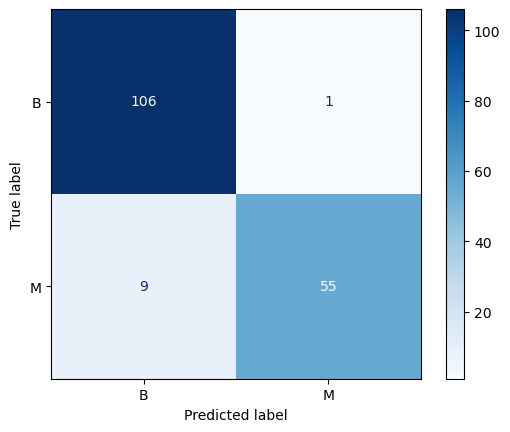

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.92      0.99      0.95       107
           M       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



Métricas númericas, entre 0 e 1. Quando mais perto de 1, melhor.

- **Precision**: “Quando o modelo disse que era essa classe, ele acertou?”
- **Recall**: “De todos os verdadeiros, quantos eu encontrei?”
- **F1-score**: Média entre precision e recall
- **Support**: Quantidade de exemplos de cada classe na base de teste

In [51]:
def calc_metrics_cls(model, X_train, y_train, X_test, y_test, cutoff):

    print("Métricas de avaliação para os dados de treino:")

    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = np.where(y_proba_train >= cutoff, "M", "B")
    
    #y_pred_train = model.predict(X_train) #cutoff padrão é 0.5
    ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
    plt.show()

    print(classification_report(y_train, y_pred_train))
    
    print("\n==============================================\n")
    print("Métricas de avaliação para os dados de teste:")

    y_proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = np.where(y_proba_test >= cutoff, "M", "B")
    
    #y_pred_test = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
    plt.show()
    
    print(classification_report(y_test, y_pred_test))

Métricas de avaliação para os dados de treino:


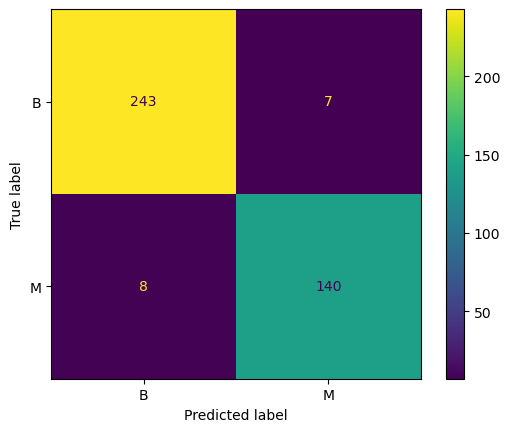

              precision    recall  f1-score   support

           B       0.97      0.97      0.97       250
           M       0.95      0.95      0.95       148

    accuracy                           0.96       398
   macro avg       0.96      0.96      0.96       398
weighted avg       0.96      0.96      0.96       398



Métricas de avaliação para os dados de teste:


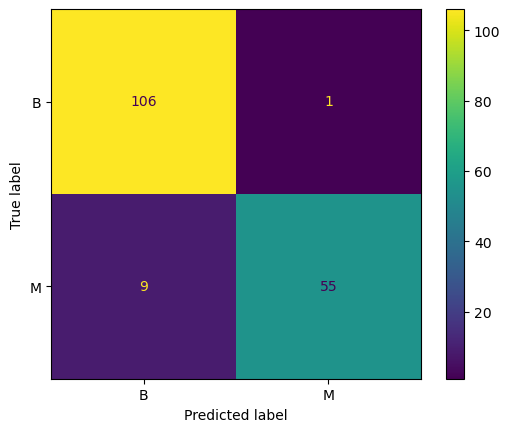

              precision    recall  f1-score   support

           B       0.92      0.99      0.95       107
           M       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



In [52]:
calc_metrics_cls(modelo, X_train, y_train, X_test, y_test, cutoff=0.5)

Métricas de avaliação para os dados de treino:


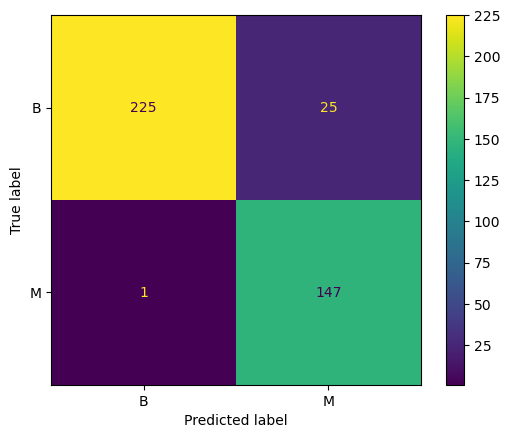

              precision    recall  f1-score   support

           B       1.00      0.90      0.95       250
           M       0.85      0.99      0.92       148

    accuracy                           0.93       398
   macro avg       0.93      0.95      0.93       398
weighted avg       0.94      0.93      0.94       398



Métricas de avaliação para os dados de teste:


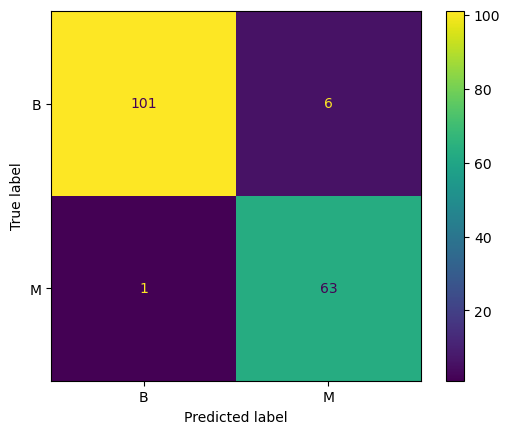

              precision    recall  f1-score   support

           B       0.99      0.94      0.97       107
           M       0.91      0.98      0.95        64

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [53]:
calc_metrics_cls(modelo, X_train, y_train, X_test, y_test, cutoff=0.1)


Cutoff: 0.1
Métricas de avaliação para os dados de treino:


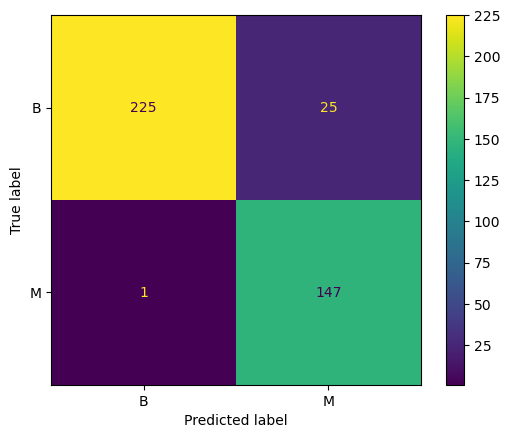

              precision    recall  f1-score   support

           B       1.00      0.90      0.95       250
           M       0.85      0.99      0.92       148

    accuracy                           0.93       398
   macro avg       0.93      0.95      0.93       398
weighted avg       0.94      0.93      0.94       398



Métricas de avaliação para os dados de teste:


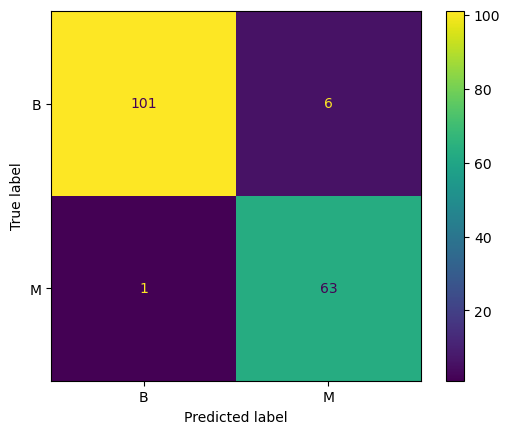

              precision    recall  f1-score   support

           B       0.99      0.94      0.97       107
           M       0.91      0.98      0.95        64

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171


Cutoff: 0.3
Métricas de avaliação para os dados de treino:


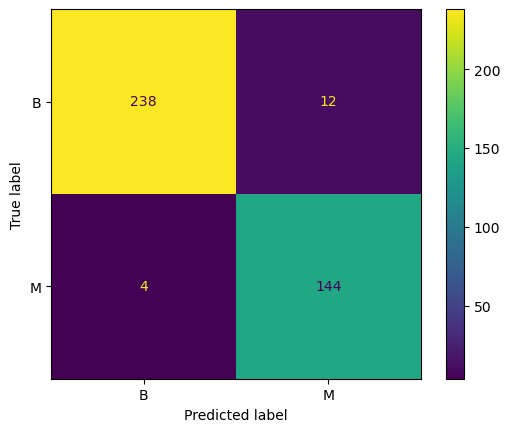

              precision    recall  f1-score   support

           B       0.98      0.95      0.97       250
           M       0.92      0.97      0.95       148

    accuracy                           0.96       398
   macro avg       0.95      0.96      0.96       398
weighted avg       0.96      0.96      0.96       398



Métricas de avaliação para os dados de teste:


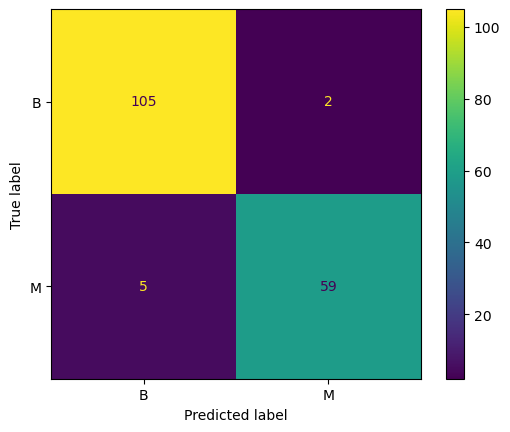

              precision    recall  f1-score   support

           B       0.95      0.98      0.97       107
           M       0.97      0.92      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171


Cutoff: 0.5
Métricas de avaliação para os dados de treino:


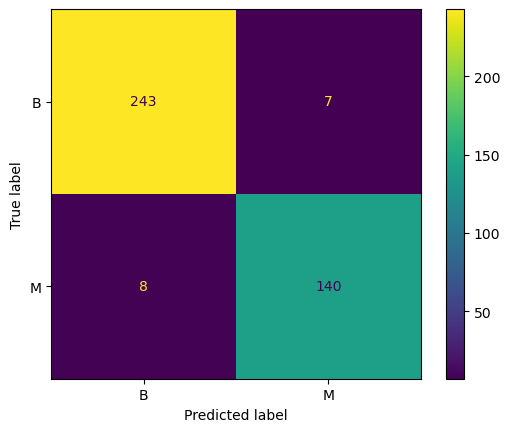

              precision    recall  f1-score   support

           B       0.97      0.97      0.97       250
           M       0.95      0.95      0.95       148

    accuracy                           0.96       398
   macro avg       0.96      0.96      0.96       398
weighted avg       0.96      0.96      0.96       398



Métricas de avaliação para os dados de teste:


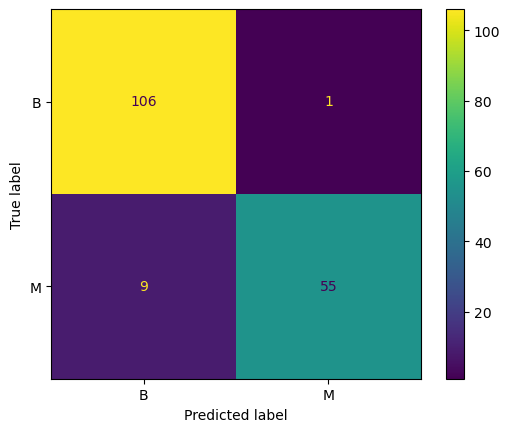

              precision    recall  f1-score   support

           B       0.92      0.99      0.95       107
           M       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


Cutoff: 0.7
Métricas de avaliação para os dados de treino:


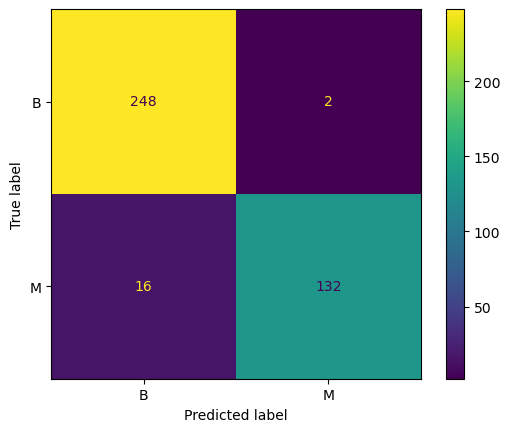

              precision    recall  f1-score   support

           B       0.94      0.99      0.96       250
           M       0.99      0.89      0.94       148

    accuracy                           0.95       398
   macro avg       0.96      0.94      0.95       398
weighted avg       0.96      0.95      0.95       398



Métricas de avaliação para os dados de teste:


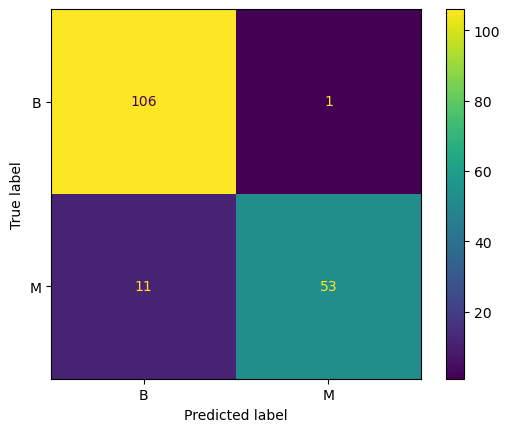

              precision    recall  f1-score   support

           B       0.91      0.99      0.95       107
           M       0.98      0.83      0.90        64

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171


Cutoff: 0.9
Métricas de avaliação para os dados de treino:


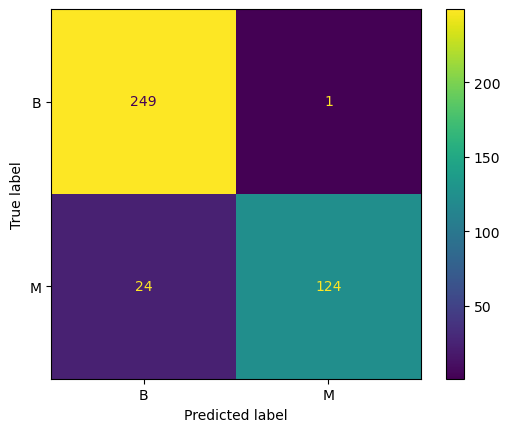

              precision    recall  f1-score   support

           B       0.91      1.00      0.95       250
           M       0.99      0.84      0.91       148

    accuracy                           0.94       398
   macro avg       0.95      0.92      0.93       398
weighted avg       0.94      0.94      0.94       398



Métricas de avaliação para os dados de teste:


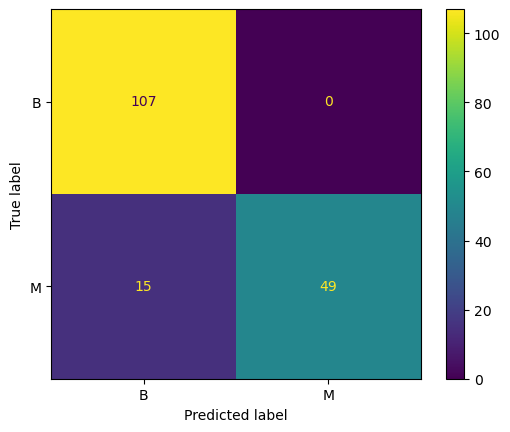

              precision    recall  f1-score   support

           B       0.88      1.00      0.93       107
           M       1.00      0.77      0.87        64

    accuracy                           0.91       171
   macro avg       0.94      0.88      0.90       171
weighted avg       0.92      0.91      0.91       171



In [54]:
for c in [0.1, 0.3, 0.5, 0.7, 0.9]:
    print(f"\nCutoff: {c}")
    calc_metrics_cls(modelo, X_train, y_train, X_test, y_test, cutoff=c)

**Cutoff (threshold)**

O cutoff (ou threshold) é simplesmente o valor que você usa para transformar probabilidade em classe.
- Se a probabilidade ≥ cutoff → classe positiva ("M")
- Se a probabilidade < cutoff → classe negativa ("B")

### Tradeoff precision/recall ###

In [57]:
from sklearn.metrics import precision_recall_curve

y_proba_test = modelo.predict_proba(X_test)[:, 1]
ps, rs, cs = precision_recall_curve(y_test, y_proba_test, pos_label="M")

Text(0, 0.5, 'Precisions')

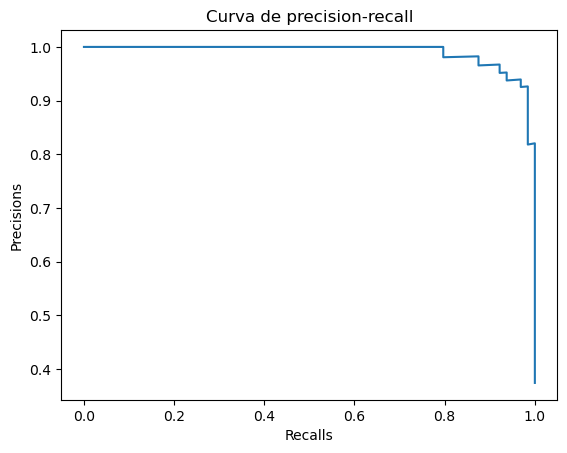

In [60]:
plt.title("Curva de precision-recall")
plt.plot(rs, ps)
plt.xlabel("Recalls")
plt.ylabel("Precisions")
# enquanto um sobe o outro desce (tradeoff)

<function matplotlib.pyplot.show(close=None, block=None)>

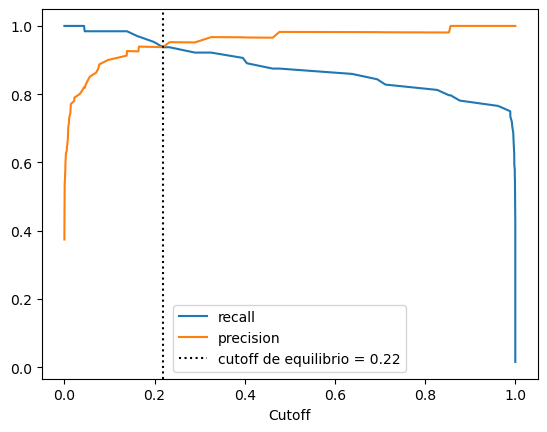

In [72]:
plt.plot(cs, rs[:-1], label="recall")
plt.plot(cs, ps[:-1], label="precision")

plt.xlabel("Cutoff")

#Ponto de encontro entre precision e recall
cutoff_eq = cs[np.where(rs == ps)][0]
plt.axvline(x=cs[np.where(rs == ps)][0], ls=":", color="k", label = f"cutoff de equilibrio = {cutoff_eq:.2f}")

plt.legend()
plt.show

### Curva ROC e AUC ROC

- AUC : Area Under the Curve
- ROC : Receiver Operating Characteristics

O valor do AUC-RC **sempre estará entre 0 e 1**, sendo que quanto mais próximo de 1, melhor o modelo, OU SEJA, tem uma taxa de verdadeiros positivos maior que a taxa de falsos positivos.

In [73]:
from sklearn.metrics import roc_curve

y_proba_test = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, cutoffs = roc_curve(y_test, y_proba_test, pos_label="M")

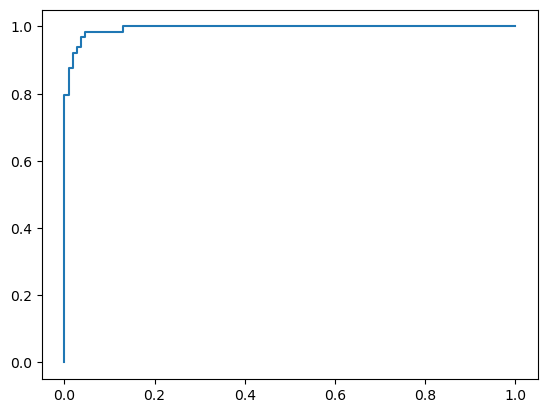

In [74]:
plt.plot(fpr, tpr)

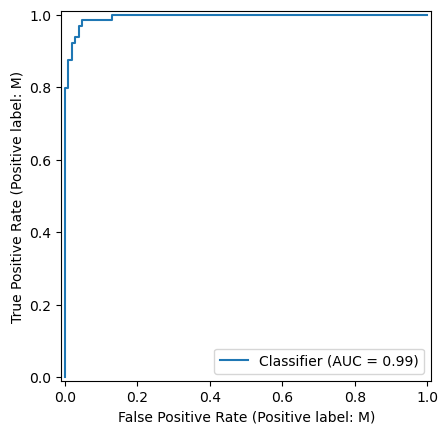

In [76]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_test, pos_label="M")

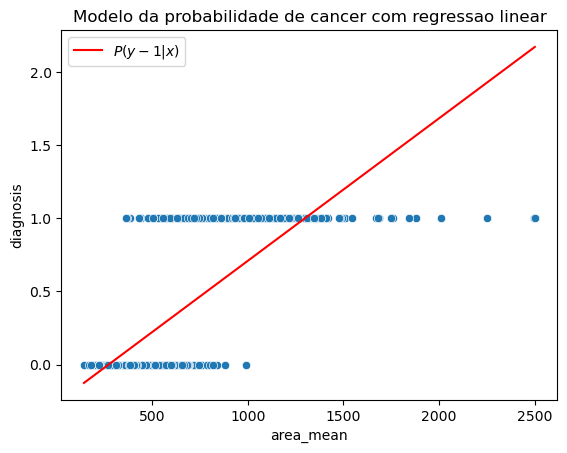

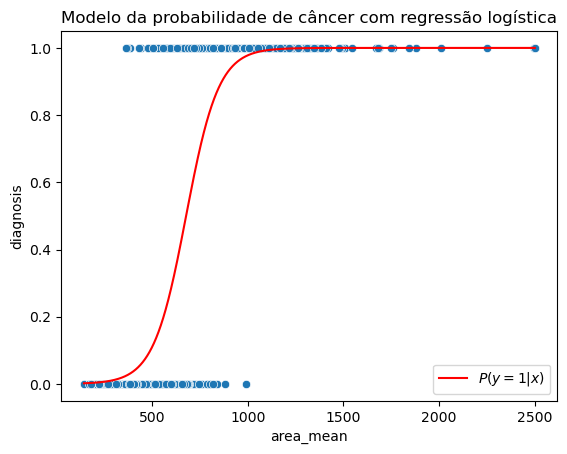

In [85]:
from sklearn.linear_model import LinearRegression, LogisticRegression

# modelos: regressão linear e logistica em termos de uma única feature (area_mean)

diagnosis_bin = df["diagnosis"].map({"B": 0,"M": 1})

lin_reg = LinearRegression().fit(df["area_mean"].values.reshape(-1, 1), diagnosis_bin)
log_reg = LogisticRegression().fit(df["area_mean"].values.reshape(-1, 1), diagnosis_bin)

# funções auxiliares para o plot

def modelo_lin_reg(lin_reg, x):
    return lin_reg.intercept_ + lin_reg.coef_[0]*x

def sigmoid(x):
    return 1/(1 + np.exp(-x))

def modelo_log_reg(log_reg, x):
    return sigmoid(log_reg.intercept_+ log_reg.coef_[0]*x)

# plot das curvas

x_min, x_max = df["area_mean"].min(), df["area_mean"].max()
x = np.linspace(x_min, x_max, 10000)

# plot das curvas
x_min, x_max = df["area_mean"].min(), df["area_mean"].max()
x = np.linspace(x_min, x_max, 10000)

# reg Lin
plt.title("Modelo da probabilidade de cancer com regressao linear")
sns.scatterplot(data=df, x="area_mean", y=diagnosis_bin)
plt.plot(x, modelo_lin_reg(lin_reg, x), color="red", label="$P(y-1| x)$")
plt.legend()
plt.show()

# reg Log
plt.title("Modelo da probabilidade de câncer com regressão logística")
sns.scatterplot(data=df, x="area_mean", y=diagnosis_bin)
plt.plot(x, modelo_log_reg(log_reg, x), color="red", label="$P(y=1|x)$")
plt.legend()
plt.show()

In [91]:
# impacto do cutoff

def plot_cutoff_impact(p_cutoff = 0.5):

    b0, b1 = log_reg.intercept_, log_reg.coef_[0]
    x_cutoff = (np.log(p_cutoff/(1-p_cutoff)) - b0)/b1
    
    hue_pred_class = df["area_mean"].apply(lambda x: "B" if x < x_cutoff else "M")
    
    plt.title(f"Breast cancer - predicao discreta com cutoff = {p_cutoff :.2f}")
    
    sns.scatterplot(data=df, x="area_mean", y=diagnosis_bin, hue=hue_pred_class)
    
    plt.plot(x, modelo_log_reg(log_reg, x), color="red", label="$P(y-1| x)$")
    
    plt.axhline(y = p_cutoff, ls=":", color="k", label=f"cutoff - {p_cutoff :.2f}")
    plt.axvline(x = x_cutoff, ls="-", color="k", label="fronteira de decisão")
    
    plt.legend()

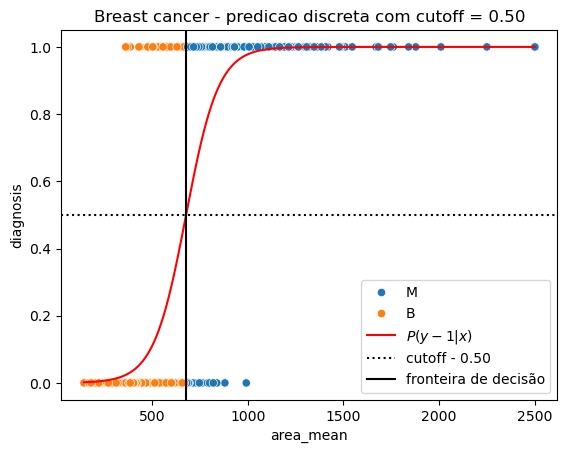

In [92]:
plot_cutoff_impact(p_cutoff = 0.5)

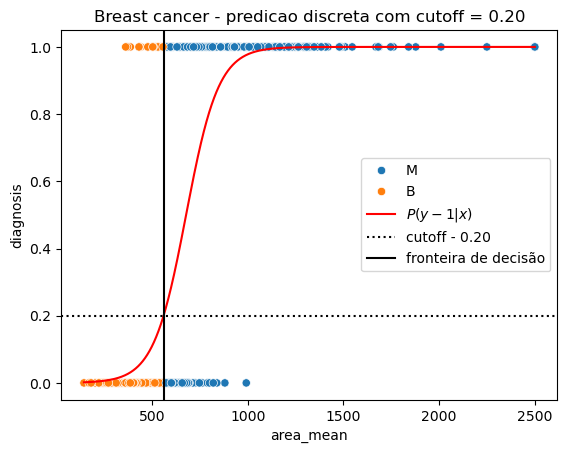

In [93]:
plot_cutoff_impact(p_cutoff = 0.2)